In [ ]:
import numpy as np
import joblib
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

PROCESSED = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iot-combined\data\processed"
RESULTS   = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iot-combined\results"
MODELS    = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iot-combined\models"

X_train = np.load(os.path.join(PROCESSED, "ciciomt2024_X_train.npy"))
X_val   = np.load(os.path.join(PROCESSED, "ciciomt2024_X_val.npy"))
X_test  = np.load(os.path.join(PROCESSED, "ciciomt2024_X_test.npy"))
y_train = np.load(os.path.join(PROCESSED, "ciciomt2024_y_train.npy"))
y_val   = np.load(os.path.join(PROCESSED, "ciciomt2024_y_val.npy"))
y_test  = np.load(os.path.join(PROCESSED, "ciciomt2024_y_test.npy"))
class_weights = joblib.load(os.path.join(PROCESSED, "ciciomt2024_class_weights.pkl"))

print(f"Train: {X_train.shape}")
print(f"TensorFlow: {tf.__version__}")

# ── Build Model ───────────────────────────────────────────────────────────
tf.random.set_seed(42)

model = keras.Sequential([
    keras.layers.Input(shape=(38,)),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=1024,
    class_weight=class_weights,
    callbacks=[early_stop], verbose=1)

print(f"\nStopped at epoch: {early_stop.stopped_epoch if early_stop.stopped_epoch > 0 else 100}")

# ── Evaluate ──────────────────────────────────────────────────────────────
def evaluate_dl(model, X, y, name):
    y_prob = model.predict(X, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    print(f"\n{name}:")
    print(f"  F1:        {f1_score(y, y_pred):.4f}")
    print(f"  AUC-ROC:   {roc_auc_score(y, y_prob):.4f}")
    print(f"  Precision: {precision_score(y, y_pred):.4f}")
    print(f"  Recall:    {recall_score(y, y_pred):.4f}")
    print(f"  Accuracy:  {accuracy_score(y, y_pred):.4f}")
    return y_pred, y_prob

y_pred_val, _  = evaluate_dl(model, X_val,  y_val,  "Validation")
y_pred_test, _ = evaluate_dl(model, X_test, y_test, "Test")

# ── Confusion Matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'])
plt.title('MLP — CICIoMT-2024', fontsize=12)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "ciciomt2024_mlp_confusion_matrix.png"), dpi=150)
plt.show()
tn, fp, fn, tp = cm.ravel()
print(f"\nTN: {tn}  FP: {fp}  FN: {fn}  TP: {tp}")

# ── Save ──────────────────────────────────────────────────────────────────
model.save(os.path.join(MODELS, "ciciomt2024_mlp.keras"))
print("Model saved.")

Train: (350000, 38)
TensorFlow: 2.21.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         9,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,201 (200.00 KB)

 Trainable params: 51,201 (200.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9695 - loss: 0.0692 - val_accuracy: 0.9944 - val_loss: 0.0198
Epoch 2/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9935 - loss: 0.0190 - val_accuracy: 0.9946 - val_loss: 0.0186
Epoch 3/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9939 - loss: 0.0176 - val_accuracy: 0.9944 - val_loss: 0.0168
Epoch 4/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9944 - loss: 0.0167 - val_accuracy: 0.9955 - val_loss: 0.0150
Epoch 5/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9945 - loss: 0.0175 - val_accuracy: 0.9951 - val_loss: 0.0156
Epoch 6/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9947 - loss: 0.0157 - val_accuracy: 0.9951 - val_loss: 0.0191
Epoch 7/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9950 - loss: 0.0131 - val_accuracy: 0.9956 - val_loss: 0.0152
Epoch 8/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9953 - loss: 0.0125 - val_accu

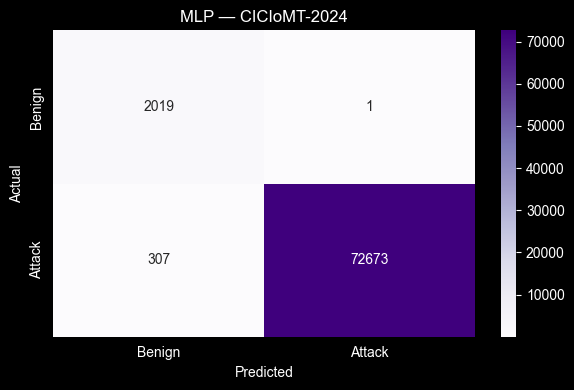


TN: 2019  FP: 1  FN: 307  TP: 72673
Model saved.


In [1]:
# ══════════════════════════════════════════════════════════════════════════
# DAY 15 SUMMARY — MLP on CICIoMT-2024
# ══════════════════════════════════════════════════════════════════════════
#
# MODEL: Multilayer Perceptron
# Config: 256→128→64, ReLU, Dropout 0.3, early stopping patience=10
# Converged at: epoch 33
#
# RESULTS:
#   F1:        0.9979
#   AUC-ROC:   0.9995
#   Precision: 1.0000  ← perfect, zero false alarms
#   Recall:    0.9958
#   Accuracy:  0.9959
#
# KEY OBSERVATION:
#   Perfect precision — MLP never raises a false alarm on this dataset.
#   Deep learning performing much stronger on CICIoMT-2024 than
#   CIC-IoT-2023 (F1=0.9786 → 0.9979). However classical ML still
#   leads on F1.
#
# CROSS-DATASET COMPARISON (MLP):
#   CIC-IoT-2023:  F1=0.9786  AUC=0.9929
#   CICIoMT-2024:  F1=0.9979  AUC=0.9995  ← +0.0193 F1 improvement
# ══════════════════════════════════════════════════════════════════════════